# GC Example 13: GC Rotation Detection

**EPS Research — Milky Way GC Corpus v1.3.2**

Baumgardt (2023) provides rotation amplitude a_rot and detection probability p_rot.
Some GCs show clear solid-body rotation.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907766  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'harris_gc_corpus_v1.3.2.jsonl': 'https://zenodo.org/records/21093446/files/harris_gc_corpus_v1.3.2.jsonl',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.2.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174

GCs with high rotation probability (p_rot>90%): 32

Cluster            a_rot    p_rot         mass
------------------------------------------------
NGC 5824            6.47     99.7      746,000
NGC 104             5.00    100.0      853,000
NGC 5139            4.27    100.0    3,940,000
NGC 5904            4.11    100.0      392,000
NGC 6273            3.44    100.0      787,000
NGC 6715            3.28     99.8    1,290,000
NGC 7078            3.25    100.0      652,000
NGC 6388            2.55     99.3    1,160,000
NGC 7089            2.54    100.0      548,000
NGC 6266            2.47    100.0      534,000


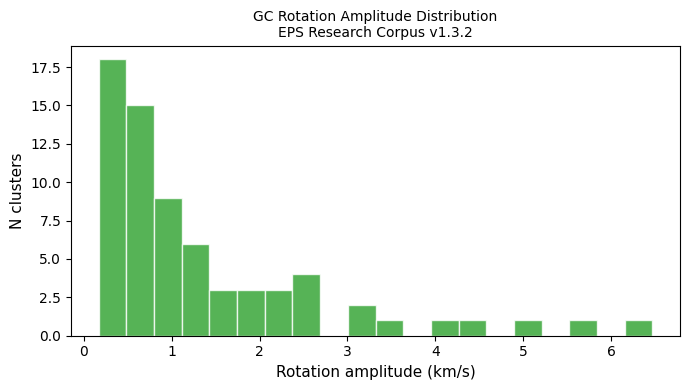

In [3]:
rotating=[c for c in clusters if c.get('baumgardt2023') and
           c['baumgardt2023'].get('p_rot_pct') is not None and
           c['baumgardt2023']['p_rot_pct']>90]
print(f"GCs with high rotation probability (p_rot>90%): {len(rotating)}")
print(f"\n{'Cluster':<15} {'a_rot':>8} {'p_rot':>8} {'mass':>12}")
print('-'*48)
for c in sorted(rotating,key=lambda x:-x['baumgardt2023']['a_rot_kms'])[:10]:
    b=c['baumgardt2023']
    print(f"{c['cluster_id']:<15} {b['a_rot_kms']:>8.2f} {b['p_rot_pct']:>8.1f} {b['mass_msun']:>12,.0f}")
a_rot=[c['baumgardt2023']['a_rot_kms'] for c in clusters
       if c.get('baumgardt2023') and c['baumgardt2023'].get('a_rot_kms') is not None]
fig,ax=plt.subplots(figsize=(7,4))
ax.hist(a_rot,bins=20,color='#2ca02c',alpha=0.8,edgecolor='white')
ax.set_xlabel('Rotation amplitude (km/s)',fontsize=11); ax.set_ylabel('N clusters',fontsize=11)
ax.set_title('GC Rotation Amplitude Distribution\nEPS Research Corpus v1.3.2',fontsize=10)
plt.tight_layout(); plt.savefig('gc13_rotation.png',dpi=150,bbox_inches='tight'); plt.show()